In [2]:
import pandas as pd

df = pd.read_csv(r"2016.csv")

In [3]:
df['date'] = pd.to_datetime(df['event_date'])
df_india = df[df['country'] == 'India'].copy()

In [4]:
# Check district coverage
print("=== Total unique districts ===")
print(df_india['admin2'].nunique())

print("\n=== Districts with most events ===")
print(df_india['admin2'].value_counts().head(20))

print("\n=== Districts with very few events ===")
dist_counts = df_india['admin2'].value_counts()
print(f"Districts with < 10 events: {(dist_counts < 10).sum()}")
print(f"Districts with < 50 events: {(dist_counts < 50).sum()}")
print(f"Districts with >= 50 events: {(dist_counts >= 50).sum()}")

# Build district-week time series
df_india['week'] = pd.to_datetime(df_india['event_date']).dt.isocalendar().week
df_india['week_year'] = pd.to_datetime(df_india['event_date']).dt.isocalendar().year

district_week = df_india[df_india['year'] < 2025].groupby(
    ['admin2', 'admin1', 'week_year', 'week']
).size().reset_index(name='count')

print("\n=== District-week panel shape ===")
print(district_week.shape)

print("\n=== Sample ===")
print(district_week[district_week['admin2']=='Ludhiana'].head(20))

=== Total unique districts ===
728

=== Districts with most events ===
admin2
Jammu                  5479
Ludhiana               2660
New Delhi              2339
Chandigarh             2282
Imphal West            2205
Srinagar               2166
Bathinda               2073
Hyderabad              1829
Amritsar               1674
Kamrup Metropolitan    1475
Darjeeling             1448
Dehradun               1445
Jalandhar              1409
Bengaluru Urban        1397
Kolkata                1397
Chennai                1373
Patiala                1298
Kathua                 1182
Sangrur                1130
West Tripura           1113
Name: count, dtype: int64

=== Districts with very few events ===
Districts with < 10 events: 34
Districts with < 50 events: 292
Districts with >= 50 events: 436



=== District-week panel shape ===
(66356, 5)

=== Sample ===
         admin2  admin1  week_year  week  count
36347  Ludhiana  Punjab       2015    53      6
36348  Ludhiana  Punjab       2016     1      4
36349  Ludhiana  Punjab       2016     2      1
36350  Ludhiana  Punjab       2016     3      7
36351  Ludhiana  Punjab       2016     4      5
36352  Ludhiana  Punjab       2016     5      9
36353  Ludhiana  Punjab       2016     6      4
36354  Ludhiana  Punjab       2016     7      5
36355  Ludhiana  Punjab       2016     8      3
36356  Ludhiana  Punjab       2016     9      1
36357  Ludhiana  Punjab       2016    11      5
36358  Ludhiana  Punjab       2016    12      5
36359  Ludhiana  Punjab       2016    13      9
36360  Ludhiana  Punjab       2016    14      4
36361  Ludhiana  Punjab       2016    15      5
36362  Ludhiana  Punjab       2016    16     13
36363  Ludhiana  Punjab       2016    17     10
36364  Ludhiana  Punjab       2016    18      3
36365  Ludhiana  Punjab   

In [6]:
import pandas as pd
import numpy as np
from itertools import product

# Create complete week grid for districts with >= 50 events only
active_districts = dist_counts[dist_counts >= 50].index.tolist()
print(f"Working with {len(active_districts)} active districts")

# Get all year-week combinations in data
df_clean_india = df_india[df_india['year'] < 2025].copy()
df_clean_india['date'] = pd.to_datetime(df_clean_india['event_date'])
df_clean_india['week_year'] = df_clean_india['date'].dt.isocalendar().year.astype(int)
df_clean_india['week'] = df_clean_india['date'].dt.isocalendar().week.astype(int)

# All weeks from 2016 to 2024
all_weeks = df_clean_india[['week_year', 'week']].drop_duplicates().sort_values(['week_year', 'week'])
print(f"Total unique weeks: {len(all_weeks)}")

# Build complete panel
print("Building complete district-week panel...")
district_state = df_india[['admin2', 'admin1']].drop_duplicates()
district_state = district_state[district_state['admin2'].isin(active_districts)]

# Cross join districts with all weeks
full_panel = all_weeks.merge(
    district_state, how='cross'
)

# Merge actual counts
actual_counts = df_clean_india[
    df_clean_india['admin2'].isin(active_districts)
].groupby(['admin2', 'week_year', 'week']).size().reset_index(name='count')

full_panel = full_panel.merge(
    actual_counts,
    on=['admin2', 'week_year', 'week'],
    how='left'
).fillna(0)

full_panel = full_panel.sort_values(['admin2', 'week_year', 'week']).reset_index(drop=True)

print(f"Full panel shape: {full_panel.shape}")
print(f"Expected: {len(active_districts)} districts × {len(all_weeks)} weeks = {len(active_districts) * len(all_weeks)}")

# Check Ludhiana
print("\nLudhiana sample:")
print(full_panel[full_panel['admin2']=='Ludhiana'].head(15))

Working with 436 active districts
Total unique weeks: 471
Building complete district-week panel...
Full panel shape: (209595, 5)
Expected: 436 districts × 471 weeks = 205356

Ludhiana sample:
        week_year  week    admin2  admin1  count
112098       2015    53  Ludhiana  Punjab    6.0
112099       2016     1  Ludhiana  Punjab    4.0
112100       2016     2  Ludhiana  Punjab    1.0
112101       2016     3  Ludhiana  Punjab    7.0
112102       2016     4  Ludhiana  Punjab    5.0
112103       2016     5  Ludhiana  Punjab    9.0
112104       2016     6  Ludhiana  Punjab    4.0
112105       2016     7  Ludhiana  Punjab    5.0
112106       2016     8  Ludhiana  Punjab    3.0
112107       2016     9  Ludhiana  Punjab    1.0
112108       2016    10  Ludhiana  Punjab    0.0
112109       2016    11  Ludhiana  Punjab    5.0
112110       2016    12  Ludhiana  Punjab    5.0
112111       2016    13  Ludhiana  Punjab    9.0
112112       2016    14  Ludhiana  Punjab    4.0


In [7]:
# Sort properly
full_panel = full_panel.sort_values(['admin2', 'week_year', 'week']).reset_index(drop=True)

# Create absolute week number for proper lag calculation
full_panel['abs_week'] = (full_panel['week_year'] - 2016) * 52 + full_panel['week']

# Per district, compute replicator dynamics features
print("Computing replicator dynamics features...")

# Group by district
full_panel = full_panel.sort_values(['admin2', 'abs_week']).reset_index(drop=True)

# x(t) = count (already have this)
# dx/dt = growth rate
full_panel['growth_rate'] = full_panel.groupby('admin2')['count'].diff(1)

# d²x/dt² = acceleration
full_panel['acceleration'] = full_panel.groupby('admin2')['growth_rate'].diff(1)

# Rolling mean (4 week window) — baseline activity level
full_panel['rolling_mean_4w'] = full_panel.groupby('admin2')['count'].transform(
    lambda x: x.rolling(4, min_periods=1).mean()
)

# Rolling std (4 week window) — volatility
full_panel['rolling_std_4w'] = full_panel.groupby('admin2')['count'].transform(
    lambda x: x.rolling(4, min_periods=1).std()
)

# Deviation from baseline — is current activity above historical average?
district_baseline = full_panel.groupby('admin2')['count'].mean().reset_index()
district_baseline.columns = ['admin2', 'baseline']
full_panel = full_panel.merge(district_baseline, on='admin2', how='left')
full_panel['deviation_from_baseline'] = full_panel['count'] - full_panel['baseline']

# Relative deviation — normalized by baseline
full_panel['relative_deviation'] = full_panel['deviation_from_baseline'] / (full_panel['baseline'] + 1)

# Is count above baseline? (proxy for above threshold)
full_panel['above_baseline'] = (full_panel['count'] > full_panel['baseline']).astype(int)

print("Features computed. Sample:")
print(full_panel[full_panel['admin2']=='Ludhiana'][
    ['week_year', 'week', 'count', 'growth_rate', 
     'acceleration', 'rolling_mean_4w', 'relative_deviation', 'above_baseline']
].head(20))

print(f"\nMissing values:\n{full_panel[['growth_rate','acceleration','rolling_mean_4w','relative_deviation']].isnull().sum()}")

Computing replicator dynamics features...
Features computed. Sample:
        week_year  week  count  growth_rate  acceleration  rolling_mean_4w  \
112098       2015    53    6.0          NaN           NaN         6.000000   
112099       2016     1    4.0         -2.0           NaN         5.000000   
112100       2016     2    1.0         -3.0          -1.0         3.666667   
112101       2016     3    7.0          6.0           9.0         4.500000   
112102       2016     4    5.0         -2.0          -8.0         4.250000   
112103       2016     5    9.0          4.0           6.0         5.500000   
112104       2016     6    4.0         -5.0          -9.0         6.250000   
112105       2016     7    5.0          1.0           6.0         5.750000   
112106       2016     8    3.0         -2.0          -3.0         5.250000   
112107       2016     9    1.0         -2.0           0.0         3.250000   
112108       2016    10    0.0         -1.0           1.0         2.25000

In [8]:
# Wave detection and labeling
# A "wave" is a period where count exceeds 2x district baseline for 2+ consecutive weeks
# "Escalating" = wave grows for 3+ weeks after onset
# "Dissipating" = wave peaks and declines within 3 weeks

print("Detecting waves...")

# Mark wave onset: count > 2x baseline
full_panel['is_wave'] = (full_panel['count'] > 2 * full_panel['baseline']).astype(int)

# For each district, find wave episodes
# A wave episode = consecutive weeks where is_wave = 1
from itertools import groupby

wave_records = []

for district, group in full_panel.groupby('admin2'):
    group = group.sort_values('abs_week').reset_index(drop=True)
    
    # Find consecutive wave periods
    wave_start = None
    in_wave = False
    
    for idx, row in group.iterrows():
        if row['is_wave'] == 1 and not in_wave:
            # Wave onset
            wave_start = idx
            in_wave = True
        elif row['is_wave'] == 0 and in_wave:
            # Wave end
            wave_end = idx - 1
            wave_length = wave_end - wave_start + 1
            
            if wave_length >= 2:  # minimum 2 weeks to be a wave
                wave_data = group.loc[wave_start:wave_end]
                onset_data = group.loc[max(0, wave_start-4):wave_start+1]
                
                # Label: escalating if count increases for 3+ weeks
                counts = wave_data['count'].values
                growth_rates = wave_data['growth_rate'].values
                
                # Escalating: peak is in second half of wave
                peak_position = counts.argmax() / max(len(counts)-1, 1)
                
                # Features at wave onset (first 2 weeks)
                onset_count = counts[0]
                onset_growth = growth_rates[1] if len(growth_rates) > 1 else 0
                onset_acceleration = wave_data['acceleration'].values[1] if len(wave_data) > 1 else 0
                pre_wave_mean = onset_data['count'].mean()
                pre_wave_trend = onset_data['growth_rate'].mean()
                
                label = 1 if peak_position > 0.4 else 0  # 1=escalating, 0=dissipating
                
                wave_records.append({
                    'district': district,
                    'state': group.loc[wave_start, 'admin1'],
                    'wave_start_week': group.loc[wave_start, 'abs_week'],
                    'wave_year': group.loc[wave_start, 'week_year'],
                    'wave_length': wave_length,
                    'peak_count': counts.max(),
                    'onset_count': onset_count,
                    'onset_growth': onset_growth,
                    'onset_acceleration': onset_acceleration,
                    'pre_wave_mean': pre_wave_mean,
                    'pre_wave_trend': pre_wave_trend,
                    'baseline': group.loc[wave_start, 'baseline'],
                    'relative_onset': onset_count / (group.loc[wave_start, 'baseline'] + 1),
                    'label': label
                })
            
            in_wave = False

waves_df = pd.DataFrame(wave_records)
print(f"Total waves detected: {len(waves_df)}")
print(f"\nLabel distribution:")
print(waves_df['label'].value_counts())
print(f"Escalating share: {waves_df['label'].mean():.3f}")

print(f"\nWave length distribution:")
print(waves_df['wave_length'].describe().round(2))

print(f"\nSample waves:")
print(waves_df.head(10))

Detecting waves...
Total waves detected: 6310

Label distribution:
label
0    4575
1    1735
Name: count, dtype: int64
Escalating share: 0.275

Wave length distribution:
count    6310.00
mean        2.62
std         1.30
min         2.00
25%         2.00
50%         2.00
75%         3.00
max        34.00
Name: wave_length, dtype: float64

Sample waves:
   district      state  wave_start_week  wave_year  wave_length  peak_count  \
0  Adilabad  Telangana              164       2019            2         1.0   
1  Adilabad  Telangana              174       2019            2         1.0   
2  Adilabad  Telangana              197       2019           10         7.0   
3  Adilabad  Telangana              231       2020            2         1.0   
4  Adilabad  Telangana              238       2020            2         1.0   
5  Adilabad  Telangana              247       2020            3         1.0   
6  Adilabad  Telangana              280       2021            2         1.0   
7  Adilabad  

In [9]:
# Stricter wave detection
# Minimum absolute count threshold AND relative threshold
# Minimum wave length of 3 weeks

MIN_ABSOLUTE = 5  # at least 5 protests per week to qualify
MIN_RELATIVE = 2.0  # at least 2x baseline
MIN_LENGTH = 3  # at least 3 weeks

full_panel['is_wave'] = (
    (full_panel['count'] > MIN_ABSOLUTE) & 
    (full_panel['count'] > MIN_RELATIVE * full_panel['baseline'])
).astype(int)

wave_records2 = []

for district, group in full_panel.groupby('admin2'):
    group = group.sort_values('abs_week').reset_index(drop=True)
    
    wave_start = None
    in_wave = False
    
    for idx, row in group.iterrows():
        if row['is_wave'] == 1 and not in_wave:
            wave_start = idx
            in_wave = True
        elif row['is_wave'] == 0 and in_wave:
            wave_end = idx - 1
            wave_length = wave_end - wave_start + 1
            
            if wave_length >= MIN_LENGTH:
                wave_data = group.loc[wave_start:wave_end]
                onset_data = group.loc[max(0, wave_start-4):wave_start+1]
                
                counts = wave_data['count'].values
                growth_rates = wave_data['growth_rate'].fillna(0).values
                
                peak_position = counts.argmax() / max(len(counts)-1, 1)
                
                wave_records2.append({
                    'district': district,
                    'state': group.loc[wave_start, 'admin1'],
                    'wave_start_week': group.loc[wave_start, 'abs_week'],
                    'wave_year': group.loc[wave_start, 'week_year'],
                    'wave_length': wave_length,
                    'peak_count': counts.max(),
                    'onset_count': counts[0],
                    'onset_growth': growth_rates[1] if len(growth_rates) > 1 else 0,
                    'onset_acceleration': wave_data['acceleration'].fillna(0).values[1] if len(wave_data) > 1 else 0,
                    'pre_wave_mean': onset_data['count'].mean(),
                    'pre_wave_trend': onset_data['growth_rate'].fillna(0).mean(),
                    'baseline': group.loc[wave_start, 'baseline'],
                    'relative_onset': counts[0] / (group.loc[wave_start, 'baseline'] + 1),
                    'label': 1 if peak_position > 0.4 else 0
                })
            
            in_wave = False

waves_df2 = pd.DataFrame(wave_records2)
print(f"Total waves detected: {len(waves_df2)}")
print(f"\nLabel distribution:")
print(waves_df2['label'].value_counts())
print(f"Escalating share: {waves_df2['label'].mean():.3f}")
print(f"\nWave length distribution:")
print(waves_df2['wave_length'].describe().round(2))
print(f"\nPeak count distribution:")
print(waves_df2['peak_count'].describe().round(2))
print(f"\nTop districts by wave count:")
print(waves_df2['district'].value_counts().head(10))

Total waves detected: 141

Label distribution:
label
0    80
1    61
Name: count, dtype: int64
Escalating share: 0.433

Wave length distribution:
count    141.00
mean       4.41
std        3.17
min        3.00
25%        3.00
50%        3.00
75%        5.00
max       34.00
Name: wave_length, dtype: float64

Peak count distribution:
count    141.00
mean      12.61
std        5.05
min        6.00
25%        9.00
50%       11.00
75%       15.00
max       36.00
Name: peak_count, dtype: float64

Top districts by wave count:
district
Chandigarh         29
Bengaluru Urban     8
Kathua              6
Bathinda            6
Imphal West         6
Darjeeling          5
Hyderabad           5
Thoubal             4
Sangrur             4
Kolkata             4
Name: count, dtype: int64


In [10]:
# Try several threshold combinations
for min_abs, min_rel, min_len in [
    (3, 1.5, 2),
    (3, 2.0, 2),
    (5, 1.5, 2),
    (3, 1.5, 3),
    (5, 1.5, 3),
]:
    full_panel['is_wave_test'] = (
        (full_panel['count'] > min_abs) & 
        (full_panel['count'] > min_rel * full_panel['baseline'])
    ).astype(int)
    
    count = 0
    for district, group in full_panel.groupby('admin2'):
        group = group.sort_values('abs_week').reset_index(drop=True)
        in_wave = False
        wave_start = None
        for idx, row in group.iterrows():
            if row['is_wave_test'] == 1 and not in_wave:
                wave_start = idx
                in_wave = True
            elif row['is_wave_test'] == 0 and in_wave:
                if (idx - wave_start) >= min_len:
                    count += 1
                in_wave = False
    
    print(f"min_abs={min_abs}, min_rel={min_rel}, min_len={min_len}: {count} waves")

min_abs=3, min_rel=1.5, min_len=2: 1012 waves
min_abs=3, min_rel=2.0, min_len=2: 750 waves
min_abs=5, min_rel=1.5, min_len=2: 480 waves
min_abs=3, min_rel=1.5, min_len=3: 418 waves
min_abs=5, min_rel=1.5, min_len=3: 223 waves


In [11]:
# Final wave detection with chosen thresholds
MIN_ABSOLUTE = 5
MIN_RELATIVE = 1.5
MIN_LENGTH = 2

full_panel['is_wave'] = (
    (full_panel['count'] > MIN_ABSOLUTE) & 
    (full_panel['count'] > MIN_RELATIVE * full_panel['baseline'])
).astype(int)

wave_records_final = []

for district, group in full_panel.groupby('admin2'):
    group = group.sort_values('abs_week').reset_index(drop=True)
    
    wave_start = None
    in_wave = False
    
    for idx, row in group.iterrows():
        if row['is_wave'] == 1 and not in_wave:
            wave_start = idx
            in_wave = True
        elif row['is_wave'] == 0 and in_wave:
            wave_end = idx - 1
            wave_length = wave_end - wave_start + 1
            
            if wave_length >= MIN_LENGTH:
                wave_data = group.loc[wave_start:wave_end]
                onset_data = group.loc[max(0, wave_start-4):wave_start+1]
                
                counts = wave_data['count'].values
                growth_rates = wave_data['growth_rate'].fillna(0).values
                accels = wave_data['acceleration'].fillna(0).values
                
                # Peak position — where in the wave does peak occur
                peak_position = counts.argmax() / max(len(counts)-1, 1)
                
                # Growth consistency — what fraction of weeks show positive growth
                growth_consistency = (growth_rates > 0).mean()
                
                # Initial momentum — average growth rate in first half
                half = max(len(counts)//2, 1)
                initial_momentum = growth_rates[:half].mean()
                
                wave_records_final.append({
                    'district': district,
                    'state': group.loc[wave_start, 'admin1'],
                    'wave_year': group.loc[wave_start, 'week_year'],
                    'wave_length': wave_length,
                    'peak_count': counts.max(),
                    'onset_count': counts[0],
                    'onset_growth': growth_rates[1] if len(growth_rates) > 1 else 0,
                    'onset_acceleration': accels[1] if len(accels) > 1 else 0,
                    'pre_wave_mean': onset_data['count'].mean(),
                    'pre_wave_trend': onset_data['growth_rate'].fillna(0).mean(),
                    'baseline': group.loc[wave_start, 'baseline'],
                    'relative_onset': counts[0] / (group.loc[wave_start, 'baseline'] + 1),
                    'growth_consistency': growth_consistency,
                    'initial_momentum': initial_momentum,
                    'label': 1 if peak_position > 0.4 else 0
                })
            
            in_wave = False

waves_final = pd.DataFrame(wave_records_final)
print(f"Total waves: {len(waves_final)}")
print(f"\nLabel distribution:")
print(waves_final['label'].value_counts())
print(f"Escalating share: {waves_final['label'].mean():.3f}")
print(f"\nWave stats:")
print(waves_final[['wave_length','peak_count','onset_count',
                    'relative_onset','growth_consistency']].describe().round(2))

Total waves: 480

Label distribution:
label
0    276
1    204
Name: count, dtype: int64
Escalating share: 0.425

Wave stats:
       wave_length  peak_count  onset_count  relative_onset  \
count       480.00      480.00       480.00          480.00   
mean          3.23       10.99         8.86            2.33   
std           2.95        4.77         3.44            1.31   
min           2.00        6.00         6.00            1.25   
25%           2.00        8.00         7.00            1.53   
50%           2.00       10.00         8.00            1.86   
75%           3.00       12.00        10.00            2.53   
max          42.00       36.00        28.00           10.38   

       growth_consistency  
count              480.00  
mean                 0.62  
std                  0.25  
min                  0.00  
25%                  0.50  
50%                  0.50  
75%                  0.80  
max                  1.00  


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Features — theoretically motivated from replicator dynamics
features = [
    'onset_count',          # initial participation level (x0)
    'onset_growth',         # initial growth rate (dx/dt at t=0)
    'onset_acceleration',   # initial acceleration (d²x/dt²)
    'relative_onset',       # how far above threshold at onset
    'pre_wave_mean',        # baseline activity before wave
    'pre_wave_trend',       # trend before wave onset
    'growth_consistency',   # fraction of weeks with positive growth
    'initial_momentum',     # average growth in first half
    'baseline',             # district baseline activity
]

# Encode state as additional feature
le = LabelEncoder()
waves_final['state_enc'] = le.fit_transform(waves_final['state'])
features.append('state_enc')

X = waves_final[features]
y = waves_final['label']

# Use cross validation — too few samples for simple train/test split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_scores = cross_val_score(lr, X, y, cv=cv, scoring='roc_auc')
lr_acc = cross_val_score(lr, X, y, cv=cv, scoring='accuracy')

print("=== Logistic Regression (5-fold CV) ===")
print(f"ROC-AUC: {lr_scores.mean():.3f} ± {lr_scores.std():.3f}")
print(f"Accuracy: {lr_acc.mean():.3f} ± {lr_acc.std():.3f}")

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    max_depth=5  # shallow to avoid overfitting on small dataset
)
rf_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
rf_acc = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')

print("\n=== Random Forest (5-fold CV) ===")
print(f"ROC-AUC: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")
print(f"Accuracy: {rf_acc.mean():.3f} ± {rf_acc.std():.3f}")

# Random baseline
print(f"\n=== Random baseline ===")
print(f"Accuracy: {max(y.mean(), 1-y.mean()):.3f}")
print(f"ROC-AUC: 0.500")

# Feature importance on full dataset
rf.fit(X, y)
print("\n=== Feature Importance ===")
for feat, imp in sorted(zip(features, rf.feature_importances_),
                         key=lambda x: -x[1]):
    print(f"{feat}: {imp:.3f}")

# Full classification report
from sklearn.model_selection import cross_val_predict
y_pred = cross_val_predict(rf, X, y, cv=cv)
print("\n=== Classification Report (RF) ===")
print(classification_report(y, y_pred))

=== Logistic Regression (5-fold CV) ===
ROC-AUC: 0.946 ± 0.006
Accuracy: 0.877 ± 0.018

=== Random Forest (5-fold CV) ===
ROC-AUC: 0.961 ± 0.012
Accuracy: 0.917 ± 0.017

=== Random baseline ===
Accuracy: 0.575
ROC-AUC: 0.500

=== Feature Importance ===
growth_consistency: 0.536
onset_growth: 0.195
onset_acceleration: 0.071
initial_momentum: 0.059
relative_onset: 0.031
onset_count: 0.029
pre_wave_mean: 0.023
baseline: 0.023
pre_wave_trend: 0.020
state_enc: 0.014

=== Classification Report (RF) ===
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       276
           1       0.91      0.89      0.90       204

    accuracy                           0.92       480
   macro avg       0.92      0.91      0.91       480
weighted avg       0.92      0.92      0.92       480



In [13]:
# Remove features computed over full wave trajectory
# Keep ONLY features observable at wave onset (first 2 weeks)

features_clean = [
    'onset_count',        # week 1 count — observable at onset
    'onset_growth',       # week 1 to 2 growth — observable after week 2
    'onset_acceleration', # acceleration by week 2 — observable after week 2
    'relative_onset',     # how far above threshold at onset
    'pre_wave_mean',      # pre-wave baseline — observable before wave
    'pre_wave_trend',     # pre-wave trend — observable before wave
    'baseline',           # district baseline — always observable
    'state_enc'           # state identity — always observable
]

# Remove growth_consistency and initial_momentum
# both computed over full wave trajectory = leakage

X_clean = waves_final[features_clean]

# Rerun cross validation
lr2 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr2_scores = cross_val_score(lr2, X_clean, y, cv=cv, scoring='roc_auc')
lr2_acc = cross_val_score(lr2, X_clean, y, cv=cv, scoring='accuracy')

print("=== Logistic Regression clean (5-fold CV) ===")
print(f"ROC-AUC: {lr2_scores.mean():.3f} ± {lr2_scores.std():.3f}")
print(f"Accuracy: {lr2_acc.mean():.3f} ± {lr2_acc.std():.3f}")

rf2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    max_depth=5
)
rf2_scores = cross_val_score(rf2, X_clean, y, cv=cv, scoring='roc_auc')
rf2_acc = cross_val_score(rf2, X_clean, y, cv=cv, scoring='accuracy')

print("\n=== Random Forest clean (5-fold CV) ===")
print(f"ROC-AUC: {rf2_scores.mean():.3f} ± {rf2_scores.std():.3f}")
print(f"Accuracy: {rf2_acc.mean():.3f} ± {rf2_acc.std():.3f}")

rf2.fit(X_clean, y)
print("\n=== Feature Importance (clean) ===")
for feat, imp in sorted(zip(features_clean, rf2.feature_importances_),
                         key=lambda x: -x[1]):
    print(f"{feat}: {imp:.3f}")

=== Logistic Regression clean (5-fold CV) ===
ROC-AUC: 0.809 ± 0.032
Accuracy: 0.744 ± 0.039

=== Random Forest clean (5-fold CV) ===
ROC-AUC: 0.873 ± 0.025
Accuracy: 0.831 ± 0.010

=== Feature Importance (clean) ===
onset_growth: 0.475
onset_acceleration: 0.150
onset_count: 0.084
relative_onset: 0.071
baseline: 0.066
pre_wave_mean: 0.060
pre_wave_trend: 0.052
state_enc: 0.041


=== Final Classification Report ===
Random baseline accuracy: 0.575
Random baseline ROC-AUC: 0.500

              precision    recall  f1-score   support

 Dissipating       0.85      0.86      0.85       276
  Escalating       0.81      0.79      0.80       204

    accuracy                           0.83       480
   macro avg       0.83      0.83      0.83       480
weighted avg       0.83      0.83      0.83       480

ROC-AUC: 0.869


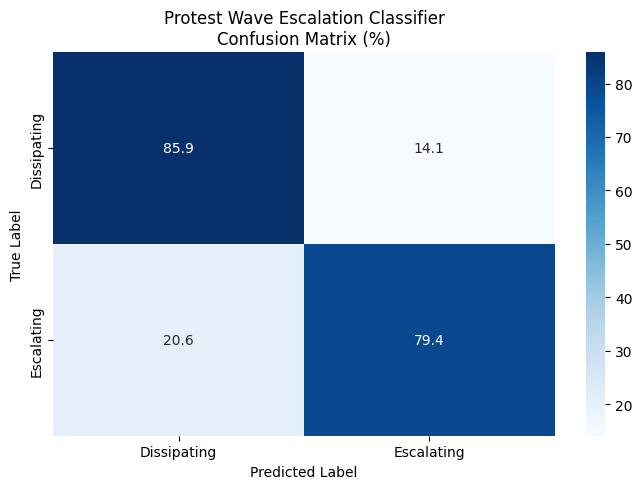

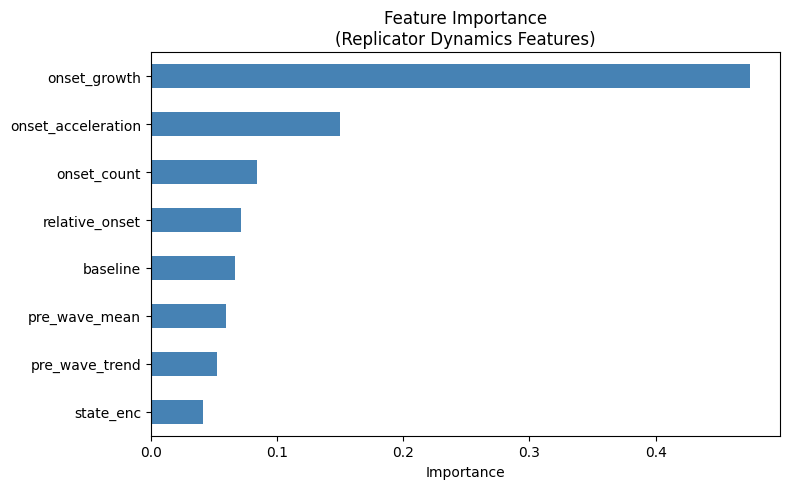

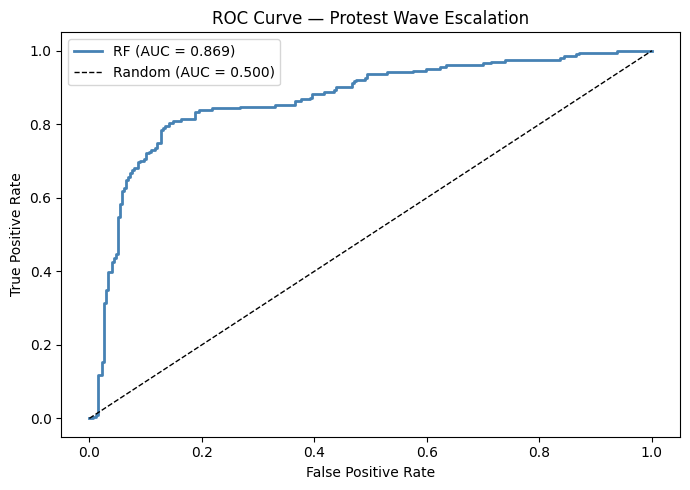

In [14]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Full classification report
y_pred_clean = cross_val_predict(rf2, X_clean, y, cv=cv)
y_prob_clean = cross_val_predict(rf2, X_clean, y, cv=cv, method='predict_proba')[:,1]

print("=== Final Classification Report ===")
print(f"Random baseline accuracy: {max(y.mean(), 1-y.mean()):.3f}")
print(f"Random baseline ROC-AUC: 0.500")
print()
print(classification_report(y, y_pred_clean, 
      target_names=['Dissipating', 'Escalating']))
print(f"ROC-AUC: {roc_auc_score(y, y_prob_clean):.3f}")

# Confusion matrix
cm = confusion_matrix(y, y_pred_clean)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(7,5))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Dissipating', 'Escalating'],
            yticklabels=['Dissipating', 'Escalating'])
plt.title('Protest Wave Escalation Classifier\nConfusion Matrix (%)', fontsize=12)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('escalation_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance plot
plt.figure(figsize=(8,5))
feat_imp = pd.Series(rf2.feature_importances_, index=features_clean).sort_values()
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance\n(Replicator Dynamics Features)', fontsize=12)
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y, y_prob_clean)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='steelblue', lw=2, 
         label=f'RF (AUC = {roc_auc_score(y, y_prob_clean):.3f})')
plt.plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Protest Wave Escalation', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()